In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [7]:
data = {
    "temperature": [30, 40, 25, 35, 28, 32, 45, 27, 31, 29],
    "humidity": [70, 30, 90, 50, 75, 65, 20, 80, 60, 72],
    "moisture": [40, 20, 80, 30, 60, 55, 15, 78, 45, 58],
    "ph": [6.5, 5.5, 7.0, 6.0, 6.8, 6.3, 5.0, 7.2, 6.4, 6.7],
    "status": [
        "Healthy",
        "Dry",
        "Fungus",
        "Dry",
        "Healthy",
        "Healthy",
        "Dry",
        "Fungus",
        "Healthy",
        "Healthy"
    ]
}

df = pd.DataFrame(data)

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   temperature  humidity  moisture   ph   status
0           30        70        40  6.5  Healthy
1           40        30        20  5.5      Dry
2           25        90        80  7.0   Fungus
3           35        50        30  6.0      Dry
4           28        75        60  6.8  Healthy


In [9]:
print("\nMissing Values:")
print(df.isnull().sum())


# ============================================
# 4. Features and Labels
# ============================================

X = df[["temperature", "humidity", "moisture", "ph"]]

y = df["status"]


Missing Values:
temperature    0
humidity       0
moisture       0
ph             0
status         0
dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (8, 4)
Testing Data Shape: (2, 4)


In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Trained Successfully")


Model Trained Successfully


In [12]:
y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)



Predictions:
['Healthy' 'Dry']


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)


Accuracy:
1.0


In [14]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

         Dry       1.00      1.00      1.00         1
     Healthy       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [15]:
joblib.dump(model, "turf_model.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


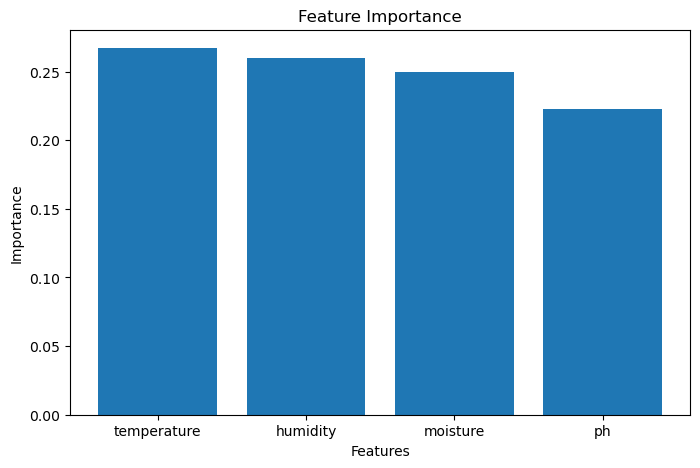

In [16]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()


In [17]:
new_data = np.array([[33, 68, 50, 6.4]])

prediction = model.predict(new_data)

print("\nNew Prediction:")
print(prediction[0])


New Prediction:
Healthy
